In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_csv('gold_data.csv')
print(df.head())


        Price               Close               High                 Low  \
0      Ticker                GC=F               GC=F                GC=F   
1        Date                 NaN                NaN                 NaN   
2  2016-01-04  1075.0999755859375             1082.5   1063.199951171875   
3  2016-01-05  1078.4000244140625             1081.5   1075.300048828125   
4  2016-01-06  1091.9000244140625  1093.699951171875  1081.5999755859375   

                 Open Volume  
0                GC=F   GC=F  
1                 NaN    NaN  
2  1063.4000244140625    143  
3  1075.5999755859375     82  
4  1081.5999755859375     52  


In [3]:
# Display basic information about the dataset
print(df.info())
#not showing summary statistics yet as all coloums were object types at this point

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530 entries, 0 to 2529
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2530 non-null   object
 1   Close   2529 non-null   object
 2   High    2529 non-null   object
 3   Low     2529 non-null   object
 4   Open    2529 non-null   object
 5   Volume  2529 non-null   object
dtypes: object(6)
memory usage: 118.7+ KB
None


Data Cleaning & Processing

In [4]:
#fixing dataset so date can have its own column
df.rename(columns={'Price': 'Date'}, inplace=True)


#dropping first two rows which are not needed
#the price data starts from the third row, the first two rows contain metadata that we don't need for our analysis
df.drop(index=[0, 1], inplace=True, errors='ignore')
df.head()

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
print(df["Date"].dtype)
print(df.head())

#converting all price data to numeric values
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
df['High'] = pd.to_numeric(df['High'], errors='coerce')
df['Low'] = pd.to_numeric(df['Low'], errors='coerce')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
print(df.dtypes)
print(df.head())

datetime64[ns]
        Date               Close                High                 Low  \
2 2016-01-04  1075.0999755859375              1082.5   1063.199951171875   
3 2016-01-05  1078.4000244140625              1081.5   1075.300048828125   
4 2016-01-06  1091.9000244140625   1093.699951171875  1081.5999755859375   
5 2016-01-07   1107.699951171875  1109.4000244140625  1091.5999755859375   
6 2016-01-08   1097.800048828125  1111.0999755859375              1093.0   

                 Open Volume  
2  1063.4000244140625    143  
3  1075.5999755859375     82  
4  1081.5999755859375     52  
5  1091.5999755859375    122  
6  1111.0999755859375     98  
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object
        Date        Close         High          Low         Open  Volume
2 2016-01-04  1075.099976  1082.500000  1063.199951  1063.400024     143
3 2016-01-05  1078.400024  1081.

In [5]:
#calulating daily returns
df['Daily Return'] = df['Close'].pct_change()
print(df.head())

        Date        Close         High          Low         Open  Volume  \
2 2016-01-04  1075.099976  1082.500000  1063.199951  1063.400024     143   
3 2016-01-05  1078.400024  1081.500000  1075.300049  1075.599976      82   
4 2016-01-06  1091.900024  1093.699951  1081.599976  1081.599976      52   
5 2016-01-07  1107.699951  1109.400024  1091.599976  1091.599976     122   
6 2016-01-08  1097.800049  1111.099976  1093.000000  1111.099976      98   

   Daily Return  
2           NaN  
3      0.003070  
4      0.012519  
5      0.014470  
6     -0.008937  


In [6]:
#calulating volatility using a rolling window of 30 days
#tells us how much the price of gold has fluctuated over the past 30 days, giving us an idea of the risk associated with investing in gold during that period
df['votaility'] = df['Daily Return'].rolling(window=30).std()
#using df.tail instead of df.head because the first 30 days of the voality column will be NaN due to the rolling window calculation 
print(df.tail())

           Date        Close         High          Low         Open  Volume  \
2525 2026-01-16  4588.399902  4608.000000  4588.399902  4608.000000     352   
2526 2026-01-20  4759.600098  4764.000000  4661.799805  4662.200195     175   
2527 2026-01-21  4831.799805  4872.299805  4771.500000  4863.500000    1706   
2528 2026-01-22  4908.799805  4908.799805  4791.899902  4791.899902    1175   
2529 2026-01-23  4976.200195  4976.200195  4936.000000  4949.600098    1175   

      Daily Return  votaility  
2525     -0.006044   0.013133  
2526      0.037312   0.014547  
2527      0.015169   0.014663  
2528      0.015936   0.014656  
2529      0.013731   0.014733  


In [7]:
#Grouping the data by "crisis" to find stablity of gold during times of crisis
#Date group 1: "stable period" from 2016 -2019
    ## for baseline volatility and returns
#Date group 2: "covid period" Feb 2020 – Dec 2020
#Date group 3: "High inflation period" March 2021 – June 2023

In [8]:
#Date group 1: "stable period" from 2016 -2019
start_date_stable = '2016-01-01'
end_date_stable = '2019-12-31'
stable_period_table = df[df['Date'].between(start_date_stable, end_date_stable)]
print(stable_period_table.head())
print(stable_period_table.tail())

        Date        Close         High          Low         Open  Volume  \
2 2016-01-04  1075.099976  1082.500000  1063.199951  1063.400024     143   
3 2016-01-05  1078.400024  1081.500000  1075.300049  1075.599976      82   
4 2016-01-06  1091.900024  1093.699951  1081.599976  1081.599976      52   
5 2016-01-07  1107.699951  1109.400024  1091.599976  1091.599976     122   
6 2016-01-08  1097.800049  1111.099976  1093.000000  1111.099976      98   

   Daily Return  votaility  
2           NaN        NaN  
3      0.003070        NaN  
4      0.012519        NaN  
5      0.014470        NaN  
6     -0.008937        NaN  
           Date        Close         High          Low         Open  Volume  \
1000 2019-12-24  1499.099976  1499.099976  1488.699951  1488.699951      52   
1001 2019-12-26  1509.300049  1512.300049  1505.000000  1505.199951     126   
1002 2019-12-27  1513.800049  1513.800049  1513.800049  1513.800049     839   
1003 2019-12-30  1514.500000  1515.099976  1510.00000

In [9]:
#date group 2: "covid period" Feb 2020 – Dec 2020
start_date_covid = '2020-02-01'
end_date_covid = '2020-12-31'
covid_period_table = df[df['Date'].between(start_date_covid, end_date_covid)]
print(covid_period_table.head())
print(covid_period_table.tail())    

           Date        Close         High          Low         Open  Volume  \
1026 2020-02-03  1577.199951  1593.300049  1568.199951  1592.900024    1062   
1027 2020-02-04  1550.400024  1577.699951  1547.800049  1577.699951     978   
1028 2020-02-05  1557.800049  1560.699951  1547.699951  1553.199951    1305   
1029 2020-02-06  1565.099976  1565.599976  1551.599976  1553.599976     110   
1030 2020-02-07  1568.599976  1571.900024  1560.500000  1564.900024     431   

      Daily Return  votaility  
1026     -0.003601   0.005610  
1027     -0.016992   0.006613  
1028      0.004773   0.006593  
1029      0.004686   0.006584  
1030      0.002236   0.006343  
           Date        Close         High          Low         Open  Volume  \
1253 2020-12-24  1879.900024  1879.900024  1875.699951  1877.300049      46   
1254 2020-12-28  1877.199951  1895.800049  1873.699951  1895.500000      75   
1255 2020-12-29  1879.699951  1881.300049  1879.699951  1881.300049     343   
1256 2020-12-30  

In [10]:
#date group 3: "high inflation period" March 2021 – June 2023
start_date_inflation = '2021-03-01'
end_date_inflation = '2023-06-30'
inflation_period_table = df[df['Date'].between(start_date_inflation, end_date_inflation)]
print(inflation_period_table.head())
print(inflation_period_table.tail())

           Date        Close         High          Low         Open  Volume  \
1296 2021-03-01  1722.500000  1747.000000  1720.300049  1737.099976     407   
1297 2021-03-02  1733.099976  1733.099976  1708.699951  1709.400024     867   
1298 2021-03-03  1715.300049  1732.400024  1703.500000  1730.000000     501   
1299 2021-03-04  1700.199951  1717.400024  1700.199951  1706.500000     521   
1300 2021-03-05  1698.000000  1701.000000  1685.000000  1690.599976     302   

      Daily Return  votaility  
1296     -0.003241   0.010332  
1297      0.006154   0.010299  
1298     -0.010271   0.010317  
1299     -0.008803   0.009888  
1300     -0.001294   0.009880  
           Date        Close         High          Low         Open  Volume  \
1880 2023-06-26  1923.699951  1928.500000  1922.500000  1922.900024      71   
1881 2023-06-27  1914.000000  1929.400024  1914.000000  1927.000000      49   
1882 2023-06-28  1912.300049  1912.300049  1912.300049  1912.300049     628   
1883 2023-06-29  

In [11]:
#finding average daily return and volatility for each period
stable_avg_return = stable_period_table['Daily Return'].mean()
stable_avg_volatility = stable_period_table['votaility'].mean()
print(f"Stable Period (2016-2019) - Average Daily Return: {stable_avg_return}, Average Volatility: {stable_avg_volatility}")

covid_avg_return = covid_period_table['Daily Return'].mean()
covid_avg_volatility = covid_period_table['votaility'].mean()
print(f"COVID Period (Feb 2020 - Dec 2020) - Average Daily Return: {covid_avg_return}, Average Volatility: {covid_avg_volatility}")

inflation_avg_return = inflation_period_table['Daily Return'].mean()
inflation_avg_volatility = inflation_period_table['votaility'].mean()
print(f"Inflation Period (March 2021 - June 2023) - Average Daily Return: {inflation_avg_return}, Average Volatility: {inflation_avg_volatility}")

Stable Period (2016-2019) - Average Daily Return: 0.00037572127776438384, Average Volatility: 0.0075248926677974615
COVID Period (Feb 2020 - Dec 2020) - Average Daily Return: 0.0008691192451843896, Average Volatility: 0.013047506940162212
Inflation Period (March 2021 - June 2023) - Average Daily Return: 0.0002220194644086603, Average Volatility: 0.009230965300344753


In [12]:
#Final Processing, Combining all the differnt groups into one table for easier comparison
stable_period_table['Period'] = '1. Stable (2016-19)'
covid_period_table['Period'] = '2. COVID (2020)'
inflation_period_table['Period'] = '3. Inflation (2021-23)'

# Combine them into one "Master" DataFrame
all_data = pd.concat([stable_period_table, covid_period_table, inflation_period_table])
print(all_data.head())
print(all_data.tail())


        Date        Close         High          Low         Open  Volume  \
2 2016-01-04  1075.099976  1082.500000  1063.199951  1063.400024     143   
3 2016-01-05  1078.400024  1081.500000  1075.300049  1075.599976      82   
4 2016-01-06  1091.900024  1093.699951  1081.599976  1081.599976      52   
5 2016-01-07  1107.699951  1109.400024  1091.599976  1091.599976     122   
6 2016-01-08  1097.800049  1111.099976  1093.000000  1111.099976      98   

   Daily Return  votaility               Period  
2           NaN        NaN  1. Stable (2016-19)  
3      0.003070        NaN  1. Stable (2016-19)  
4      0.012519        NaN  1. Stable (2016-19)  
5      0.014470        NaN  1. Stable (2016-19)  
6     -0.008937        NaN  1. Stable (2016-19)  
           Date        Close         High          Low         Open  Volume  \
1880 2023-06-26  1923.699951  1928.500000  1922.500000  1922.900024      71   
1881 2023-06-27  1914.000000  1929.400024  1914.000000  1927.000000      49   
1882 2

/var/folders/2x/6gzzd9y13nd182602n9gdtr40000gn/T/ipykernel_35734/415267965.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stable_period_table['Period'] = '1. Stable (2016-19)'
/var/folders/2x/6gzzd9y13nd182602n9gdtr40000gn/T/ipykernel_35734/415267965.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid_period_table['Period'] = '2. COVID (2020)'
/var/folders/2x/6gzzd9y13nd182602n9gdtr40000gn/T/ipykernel_35734/415267965.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

Visualization

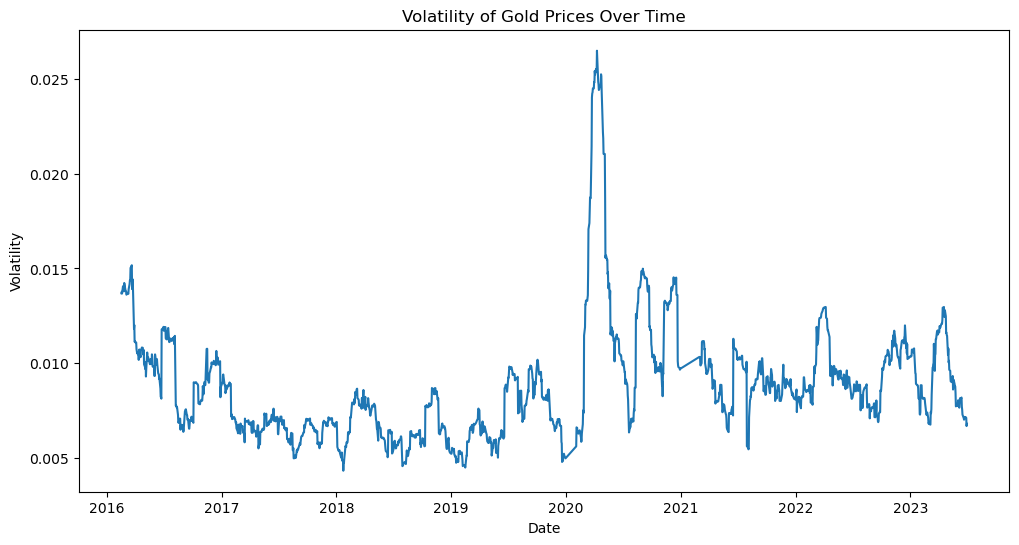

In [13]:
#time series plot to show volatility of gold prices over time
plt.figure(figsize=(12, 6))
plt.plot(all_data['Date'], all_data['votaility'])
plt.title('Volatility of Gold Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

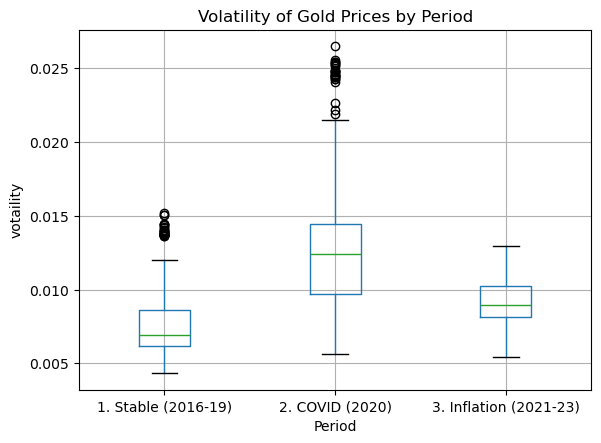

In [14]:
#Boxplot to show volatility of gold prices by period
all_data.boxplot(column='votaility', by='Period')
plt.title('Volatility of Gold Prices by Period')
plt.suptitle('')
plt.xlabel('Period')
plt.ylabel('votaility')
plt.show()

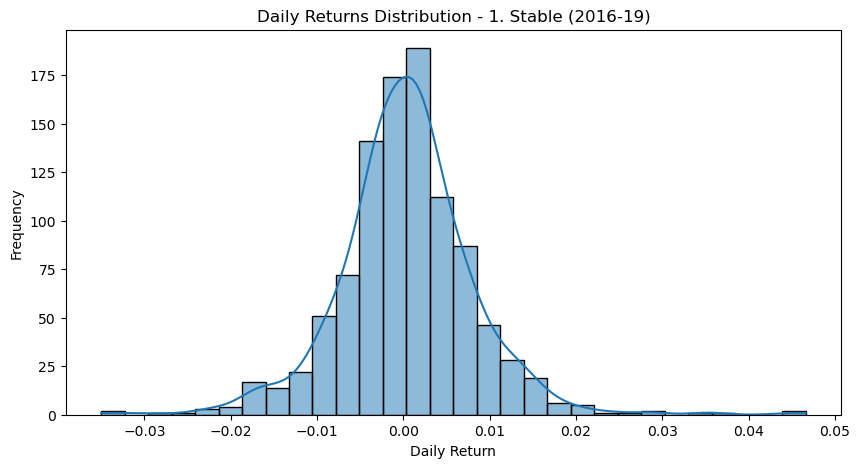

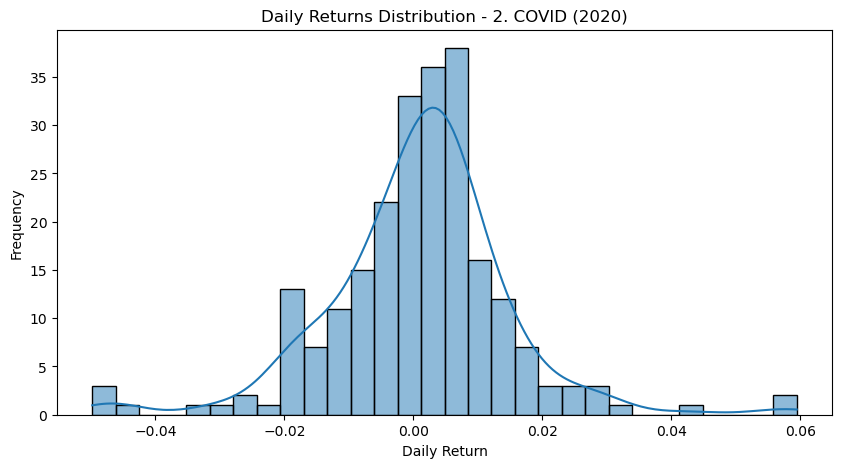

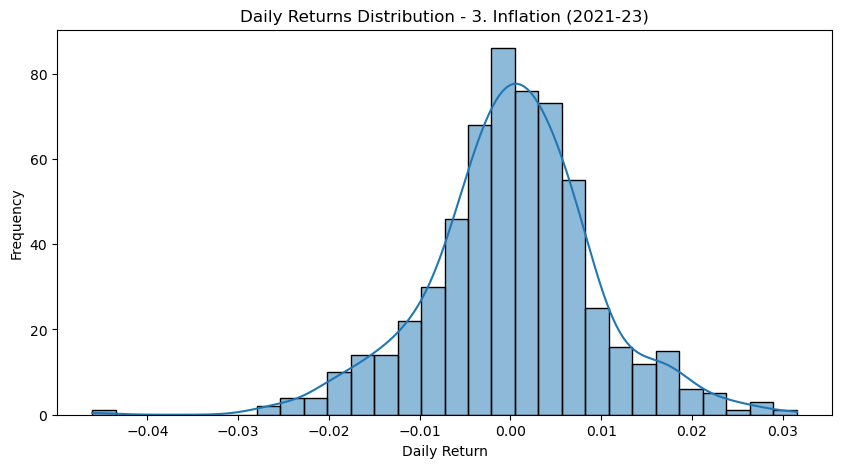

In [15]:
#Histogram of Daily Returns by Period
for period in all_data['Period'].unique():
    subset = all_data[all_data['Period'] == period]
    plt.figure(figsize=(10, 5))
    sns.histplot(subset['Daily Return'], bins=30, kde=True)
    plt.title(f'Daily Returns Distribution - {period}')
    plt.xlabel('Daily Return')
    plt.ylabel('Frequency')
    plt.show()